# Predictive Modeling Using Machine Learning

Internship task: build a model to predict outcomes based on given data — applying Logistic Regression, Decision Tree, and Random Forest, then evaluating with accuracy, confusion matrices, and ROC curves.

## 1. Load Data

Dataset: customer churn — predicting whether a telecom customer will churn (leave) based on their usage and account details.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/customer_churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (2000, 11)


,customer_id,age,tenure_months,contract_type,monthly_charges,total_charges,internet_addon,support_calls,tech_issues_reported,payment_delay_days,churned
0,10001,51,52,Two Year,45.47,2320.48,No,2,0,0,0
1,10002,33,15,Month-to-Month,104.09,1607.69,No,0,0,0,0
2,10003,42,61,One Year,23.84,1352.30,No,1,1,5,0
3,10004,54,21,Month-to-Month,110.18,2117.94,No,2,0,2,1
4,10005,25,24,One Year,66.15,1352.89,No,1,1,0,0


## 2. Explore the Data

In [2]:
print(df.info())
print("\nChurn rate:", df['churned'].mean().round(3))
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           2000 non-null   int64  
 1   age                   2000 non-null   int64  
 2   tenure_months         2000 non-null   int64  
 3   contract_type         2000 non-null   str    
 4   monthly_charges       2000 non-null   float64
 5   total_charges         2000 non-null   float64
 6   internet_addon        2000 non-null   str    
 7   support_calls         2000 non-null   int64  
 8   tech_issues_reported  2000 non-null   int64  
 9   payment_delay_days    2000 non-null   int64  
 10  churned               2000 non-null   int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 172.0 KB
None

Churn rate: 0.491


,customer_id,age,tenure_months,monthly_charges,total_charges,support_calls,tech_issues_reported,payment_delay_days,churned
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,11000.500000,45.611000,35.191500,69.849745,2331.946110,1.472000,0.791000,2.384000,0.491000
std,577.494589,16.689816,20.516366,28.805891,1784.971544,1.179793,0.895388,2.814161,0.500044
min,10001.000000,18.000000,1.000000,20.000000,24.110000,0.000000,0.000000,0.000000,0.000000
25%,10500.750000,31.000000,17.000000,45.190000,889.002500,1.000000,0.000000,0.000000,0.000000
50%,11000.500000,45.000000,35.000000,70.140000,1906.850000,1.000000,1.000000,1.500000,0.000000
75%,11500.250000,60.000000,53.000000,94.865000,3449.532500,2.000000,1.000000,3.000000,1.000000
max,12000.000000,74.000000,71.000000,119.960000,8479.140000,7.000000,5.000000,19.000000,1.000000


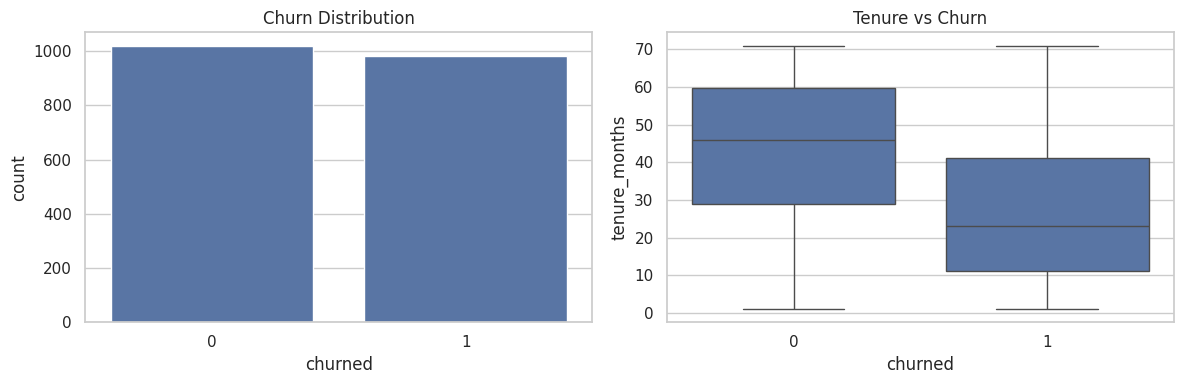

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="churned", ax=axes[0])
axes[0].set_title("Churn Distribution")
sns.boxplot(data=df, x="churned", y="tenure_months", ax=axes[1])
axes[1].set_title("Tenure vs Churn")
plt.tight_layout()
plt.show()

## 3. Prepare Features & Train/Test Split

In [4]:
le_contract = LabelEncoder()
le_addon = LabelEncoder()
df["contract_type_enc"] = le_contract.fit_transform(df["contract_type"])
df["internet_addon_enc"] = le_addon.fit_transform(df["internet_addon"])

feature_cols = ["age", "tenure_months", "contract_type_enc", "monthly_charges",
                 "total_charges", "internet_addon_enc", "support_calls",
                 "tech_issues_reported", "payment_delay_days"]
X = df[feature_cols]
y = df["churned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (1600, 9)  Test: (400, 9)


## 4. Train Models: Logistic Regression, Decision Tree, Random Forest

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
}

results = {}
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": model, "y_pred": y_pred, "y_proba": y_proba,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_proba),
    }

comparison = pd.DataFrame({n: {k: v for k, v in r.items() if k in ["accuracy","precision","recall","f1","auc"]} for n, r in results.items()}).T.round(3)
comparison

,accuracy,precision,recall,f1,auc
Logistic Regression,0.728,0.708,0.755,0.731,0.795
Decision Tree,0.680,0.677,0.663,0.670,0.740
Random Forest,0.698,0.694,0.684,0.689,0.773


## 5. Confusion Matrices

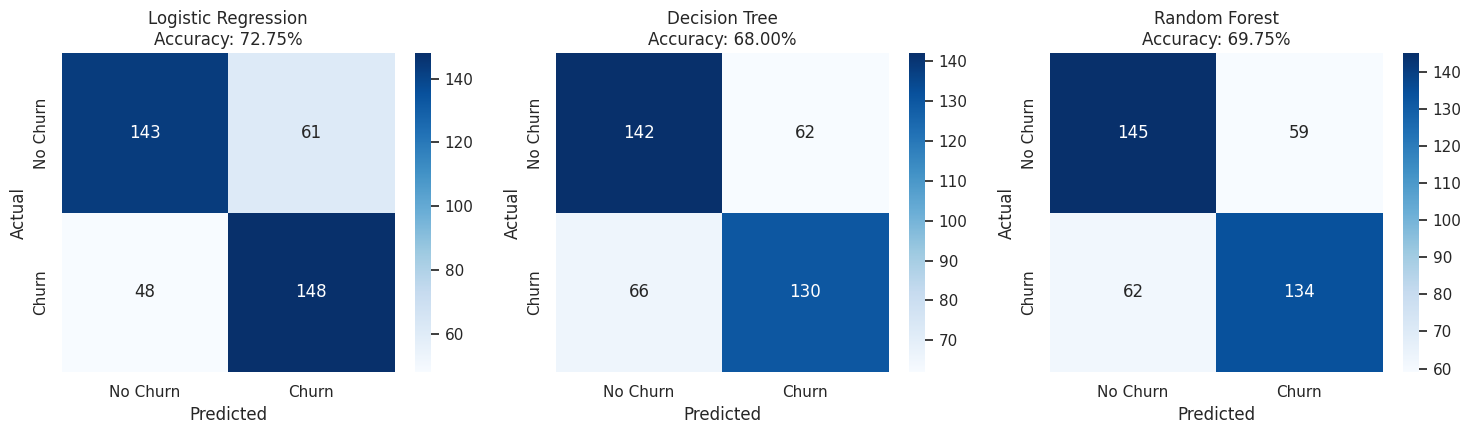

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn","Churn"], yticklabels=["No Churn","Churn"])
    ax.set_title(f"{name}\nAccuracy: {res['accuracy']:.2%}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 6. ROC Curves

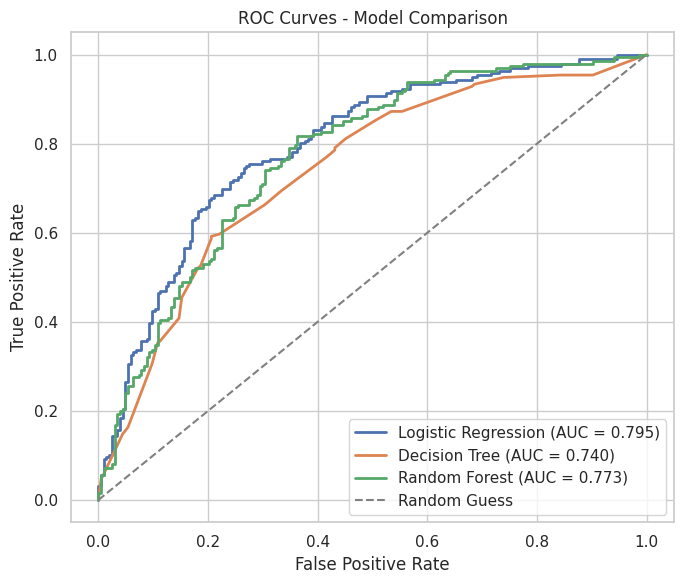

In [7]:
plt.figure(figsize=(7,6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})", linewidth=2)
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Feature Importance (Random Forest)

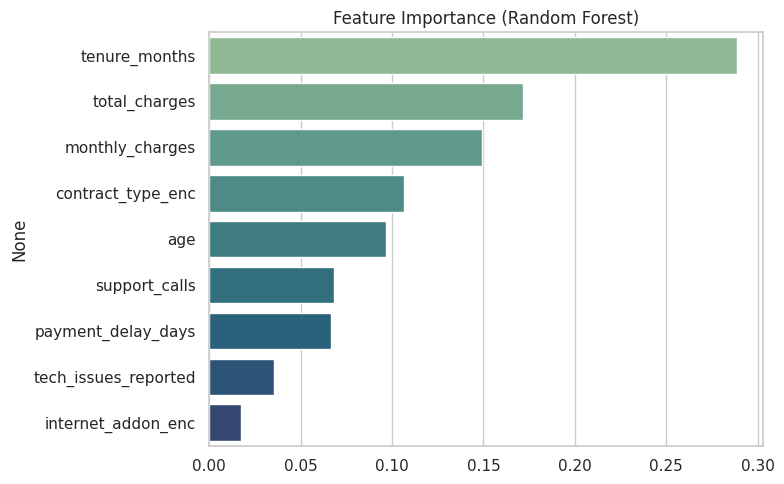

In [8]:
rf = results["Random Forest"]["model"]
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, legend=False, palette="crest")
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

## 8. Best Model Report

In [9]:
best_name = comparison["accuracy"].idxmax()
print(f"Best model: {best_name}\n")
print(classification_report(y_test, results[best_name]["y_pred"]))

Best model: Logistic Regression

              precision    recall  f1-score   support

           0       0.75      0.70      0.72       204
           1       0.71      0.76      0.73       196

    accuracy                           0.73       400
   macro avg       0.73      0.73      0.73       400
weighted avg       0.73      0.73      0.73       400

